In [ ]:
#!/usr/bin/env python3
"""
Cross-Task Knowledge Transfer Analysis

This script tests how well padding vs masking versions can transfer knowledge
between different tasks. It trains on each task and then tests performance
on all tasks to measure knowledge transfer capabilities.

Tasks: CartPole, MountainCar, Acrobot
Versions: Padding (Version B) vs Masking (Version D)
"""

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import sys
import os
import time
from typing import Dict, List, Tuple, Any
import json
import itertools

# Add src to path
sys.path.append('src')

from src.topologies.fully_connected import FullyConnectedTopology
from src.topologies.small_world import SmallWorldTopology
from src.topologies.modular import ModularTopology
from src.topologies.hybrid import HybridTopology
from src.networks.ffn import FeedForwardNetwork

class CrossTaskCallback(BaseCallback):
    """Enhanced callback to track training metrics for cross-task analysis."""
    
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.value_losses = []
        self.policy_losses = []
        self.entropy_losses = []
        self.current_episode_reward = 0
        self.current_episode_length = 0
        
    def _on_step(self) -> bool:
        # Track episode rewards and lengths
        if len(self.training_env.buf_rews) > 0:
            self.current_episode_reward += self.training_env.buf_rews[0]
            self.current_episode_length += 1
            
            if self.training_env.buf_dones[0]:
                self.episode_rewards.append(self.current_episode_reward)
                self.episode_lengths.append(self.current_episode_length)
                self.current_episode_reward = 0
                self.current_episode_length = 0
        
        # Track losses if available
        if hasattr(self.model, 'logger') and self.model.logger.name_to_value:
            if 'train/value_loss' in self.model.logger.name_to_value:
                self.value_losses.append(self.model.logger.name_to_value['train/value_loss'])
            if 'train/policy_loss' in self.model.logger.name_to_value:
                self.policy_losses.append(self.model.logger.name_to_value['train/policy_loss'])
            if 'train/entropy_loss' in self.model.logger.name_to_value:
                self.entropy_losses.append(self.model.logger.name_to_value['train/entropy_loss'])
        
        return True

class VersionB_PaddingPolicy_2Layers(ActorCriticPolicy):
    """Version B: Universal 2-layer topology with padding/truncation."""
    
    def __init__(self, observation_space, action_space, lr_schedule, topology_type='fully_connected', *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        self.topology_type = topology_type
        self.task_input_dim = observation_space.shape[0]
        self.task_output_dim = action_space.n
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        print(f"[Version B - 2 Layers] Task: {self.task_input_dim}→{self.task_output_dim} Topology: {self.topology_type}")
        print(f"[Version B - 2 Layers] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        self._create_topology_network()
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n)
        )
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def _create_topology_network(self):
        layer_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        if self.topology_type == 'fully_connected':
            topology = FullyConnectedTopology(
                size=layer_size,
                num_layers=2,
                inter_layer_prob=1.0,
                intra_layer_prob=1.0,
                seed=42
            )
        elif self.topology_type == 'small_world':
            topology = SmallWorldTopology(
                size=layer_size,
                k=4,
                p=0.1,
                num_layers=2,
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'modular':
            topology = ModularTopology(
                size=layer_size,
                num_modules=4,
                inter_module_prob=0.1,
                intra_module_prob=0.3,
                num_layers=2,
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'hybrid':
            topology = HybridTopology(
                size=layer_size,
                num_modules=4,
                k=4,
                p=0.1,
                inter_module_prob=0.1,
                num_layers=2,
                inter_layer_prob=0.1,
                seed=42
            )
        else:
            raise ValueError(f"Unknown topology type: {self.topology_type}")
        graphs = topology.generate(2)
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        network_params = {'learning_rate': 0.001, 'activation': 'tanh'}
        self.layer1_network = FeedForwardNetwork(graphs[0], input_nodes, output_nodes, network_params)
        self.layer2_network = FeedForwardNetwork(graphs[1], input_nodes, output_nodes, network_params)
    
    def _pad_input(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        if x.shape[1] < self.universal_input_dim:
            padding = torch.zeros(batch_size, self.universal_input_dim - x.shape[1], device=x.device)
            return torch.cat([x, padding], dim=1)
        else:
            return x[:, :self.universal_input_dim]
    
    def _truncate_output(self, x: torch.Tensor) -> torch.Tensor:
        return x[:, :self.task_output_dim]
    
    def forward_actor(self, obs):
        features = self.extract_features(obs)
        universal_input = self._pad_input(features)
        
        # Layer 1
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Layer 2
        layer2_input = self._pad_input(layer1_tensor)
        layer2_input_dict = {i: layer2_input[:, i] for i in range(self.universal_input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        universal_output = torch.stack(layer2_values, dim=1)
        
        task_output = self._truncate_output(universal_output)
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        features = self.extract_features(obs)
        universal_input = self._pad_input(features)
        
        # Layer 1
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Layer 2
        layer2_input = self._pad_input(layer1_tensor)
        layer2_input_dict = {i: layer2_input[:, i] for i in range(self.universal_input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        universal_output = torch.stack(layer2_values, dim=1)
        
        task_output = self._truncate_output(universal_output)
        return self.critic_head(task_output)
    
    def get_weight_stats(self):
        stats = {}
        for name, param in self.named_parameters():
            if param.requires_grad:
                stats[name] = {
                    'mean': param.data.mean().item(),
                    'std': param.data.std().item(),
                    'min': param.data.min().item(),
                    'max': param.data.max().item(),
                    'norm': param.data.norm().item()
                }
        return stats

class VersionD_MaskingPolicy_2Layers(ActorCriticPolicy):
    """Version D: Universal 2-layer topology with masking instead of padding."""
    def __init__(self, observation_space, action_space, lr_schedule, topology_type='fully_connected', *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        self.topology_type = topology_type
        self.task_input_dim = observation_space.shape[0]
        self.task_output_dim = action_space.n
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        print(f"[Version D - 2 Layers] Task: {self.task_input_dim}→{self.task_output_dim} Topology: {self.topology_type}")
        print(f"[Version D - 2 Layers] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        self._create_topology_network()
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n)
        )
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def _create_topology_network(self):
        layer_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        if self.topology_type == 'fully_connected':
            topology = FullyConnectedTopology(
                size=layer_size,
                num_layers=2,
                inter_layer_prob=1.0,
                intra_layer_prob=1.0,
                seed=42
            )
        elif self.topology_type == 'small_world':
            topology = SmallWorldTopology(
                size=layer_size,
                k=4,
                p=0.1,
                num_layers=2,
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'modular':
            topology = ModularTopology(
                size=layer_size,
                num_modules=4,
                inter_module_prob=0.1,
                intra_module_prob=0.3,
                num_layers=2,
                inter_layer_prob=0.1,
                seed=42
            )
        elif self.topology_type == 'hybrid':
            topology = HybridTopology(
                size=layer_size,
                num_modules=4,
                k=4,
                p=0.1,
                inter_module_prob=0.1,
                num_layers=2,
                inter_layer_prob=0.1,
                seed=42
            )
        else:
            raise ValueError(f"Unknown topology type: {self.topology_type}")
        graphs = topology.generate(2)
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        network_params = {'learning_rate': 0.001, 'activation': 'tanh'}
        self.layer1_network = FeedForwardNetwork(graphs[0], input_nodes, output_nodes, network_params)
        self.layer2_network = FeedForwardNetwork(graphs[1], input_nodes, output_nodes, network_params)
    
    def _create_input_mask(self, x: torch.Tensor) -> torch.Tensor:
        """Create a mask for input nodes based on actual input dimensions."""
        batch_size = x.shape[0]
        mask = torch.zeros(batch_size, self.universal_input_dim, device=x.device)
        
        # Set mask to 1 for actual input dimensions, 0 for padding
        actual_dim = min(x.shape[1], self.universal_input_dim)
        mask[:, :actual_dim] = 1.0
        
        return mask
    
    def _create_output_mask(self) -> torch.Tensor:
        """Create a mask for output nodes based on task output dimensions."""
        # For now, we'll use a simple approach - mask out unused output dimensions
        # In practice, this could be more sophisticated
        mask = torch.ones(self.universal_output_dim)
        if self.task_output_dim < self.universal_output_dim:
            mask[self.task_output_dim:] = 0.0
        return mask
    
    def _apply_input_masking(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """Apply masking to input, setting masked values to 0."""
        # Pad or truncate input to universal dimension
        batch_size = x.shape[0]
        if x.shape[1] < self.universal_input_dim:
            padding = torch.zeros(batch_size, self.universal_input_dim - x.shape[1], device=x.device)
            padded_input = torch.cat([x, padding], dim=1)
        else:
            padded_input = x[:, :self.universal_input_dim]
        
        # Apply mask
        return padded_input * mask
    
    def _apply_output_masking(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """Apply masking to output, keeping only relevant dimensions."""
        # Apply mask to output
        masked_output = x * mask.unsqueeze(0).expand(x.shape[0], -1)
        
        # Return only the task-relevant dimensions
        return masked_output[:, :self.task_output_dim]
    
    def forward_actor(self, obs):
        features = self.extract_features(obs)
        
        # Create masks
        input_mask = self._create_input_mask(features)
        output_mask = self._create_output_mask().to(features.device)
        
        # Apply input masking
        universal_input = self._apply_input_masking(features, input_mask)
        
        # Layer 1
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Apply output masking to layer 1
        layer1_masked = self._apply_output_masking(layer1_tensor, output_mask)
        
        # Layer 2 - use masked layer 1 output as input
        layer2_input = self._apply_input_masking(layer1_masked, input_mask)
        layer2_input_dict = {i: layer2_input[:, i] for i in range(self.universal_input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        universal_output = torch.stack(layer2_values, dim=1)
        
        # Apply final output masking
        task_output = self._apply_output_masking(universal_output, output_mask)
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        features = self.extract_features(obs)
        
        # Create masks
        input_mask = self._create_input_mask(features)
        output_mask = self._create_output_mask().to(features.device)
        
        # Apply input masking
        universal_input = self._apply_input_masking(features, input_mask)
        
        # Layer 1
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        layer1_output = self.layer1_network.forward(input_dict)
        
        layer1_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer1_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer1_values.append(val)
        layer1_tensor = torch.stack(layer1_values, dim=1)
        
        # Apply output masking to layer 1
        layer1_masked = self._apply_output_masking(layer1_tensor, output_mask)
        
        # Layer 2 - use masked layer 1 output as input
        layer2_input = self._apply_input_masking(layer1_masked, input_mask)
        layer2_input_dict = {i: layer2_input[:, i] for i in range(self.universal_input_dim)}
        layer2_output = self.layer2_network.forward(layer2_input_dict)
        
        layer2_values = []
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = layer2_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            layer2_values.append(val)
        universal_output = torch.stack(layer2_values, dim=1)
        
        # Apply final output masking
        task_output = self._apply_output_masking(universal_output, output_mask)
        return self.critic_head(task_output)
    
    def get_weight_stats(self):
        stats = {}
        for name, param in self.named_parameters():
            if param.requires_grad:
                stats[name] = {
                    'mean': param.data.mean().item(),
                    'std': param.data.std().item(),
                    'min': param.data.min().item(),
                    'max': param.data.max().item(),
                    'norm': param.data.norm().item()
                }
        return stats

def make_env(env_name):
    """Create environment with proper setup."""
    def _make_env():
        env = gym.make(env_name)
        return env
    return _make_env

def train_and_test_policy(policy_class, policy_name, train_task, test_tasks, topology_type, total_timesteps=200000):
    print(f"\n🎯 Training {policy_name} on {train_task} with topology {topology_type}")
    print("=" * 60)
    
    # Train the model on the training task
    train_env = DummyVecEnv([make_env(train_task)])
    train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True)
    callback = CrossTaskCallback()
    start_time = time.time()
    model = PPO(
        lambda *args, **kwargs: policy_class(*args, topology_type=topology_type, **kwargs),
        train_env,
        learning_rate=3e-4,
        n_steps=2048,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        clip_range_vf=None,
        normalize_advantage=True,
        ent_coef=0.0,
        vf_coef=0.5,
        max_grad_norm=0.5,
        use_sde=False,
        sde_sample_freq=-1,
        target_kl=None,
        tensorboard_log=None,
        policy_kwargs=dict(),
        verbose=0,
        seed=42,
        device='auto',
        _init_setup_model=True
    )
    model.learn(total_timesteps=total_timesteps, callback=callback)
    training_time = time.time() - start_time
    print(f"✅ Training completed in {training_time:.1f}s")
    
    # Save the trained model's weights
    trained_weights = {}
    for name, param in model.policy.named_parameters():
        if param.requires_grad:
            trained_weights[name] = param.data.clone()
    
    results = {}
    for test_task in test_tasks:
        print(f"\n🧪 Testing on {test_task}")
        
        # Create a new model for this test task with the same policy class
        test_env = DummyVecEnv([make_env(test_task)])
        test_env = VecNormalize(test_env, norm_obs=True, norm_reward=True)
        
        test_model = PPO(
            lambda *args, **kwargs: policy_class(*args, topology_type=topology_type, **kwargs),
            test_env,
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=64,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.2,
            clip_range_vf=None,
            normalize_advantage=True,
            ent_coef=0.0,
            vf_coef=0.5,
            max_grad_norm=0.5,
            use_sde=False,
            sde_sample_freq=-1,
            target_kl=None,
            tensorboard_log=None,
            policy_kwargs=dict(),
            verbose=0,
            seed=42,
            device='auto',
            _init_setup_model=True
        )
        
        # Load the trained weights into the test model
        with torch.no_grad():
            for name, param in test_model.policy.named_parameters():
                if name in trained_weights and param.shape == trained_weights[name].shape:
                    param.data.copy_(trained_weights[name])
        
        test_rewards = []
        test_lengths = []
        for episode in range(10):
            obs = test_env.reset()
            if isinstance(obs, tuple):
                obs = obs[0]  # Handle new gym API
            total_reward = 0
            episode_length = 0
            done = False
            while not done:
                action, _ = test_model.predict(obs, deterministic=True)
                obs, reward, done, info = test_env.step(action)
                total_reward += reward[0]
                episode_length += 1
                done = done[0]
            test_rewards.append(total_reward)
            test_lengths.append(episode_length)
        avg_reward = np.mean(test_rewards)
        std_reward = np.std(test_rewards)
        results[test_task] = {
            'avg_reward': avg_reward,
            'std_reward': std_reward,
            'test_rewards': test_rewards,
            'test_lengths': test_lengths
        }
        print(f"  Average reward: {avg_reward:.2f} ± {std_reward:.2f}")
        print(f"  Reward range: {min(test_rewards):.0f} - {max(test_rewards):.0f}")
    
    weight_stats = model.policy.get_weight_stats() if hasattr(model.policy, 'get_weight_stats') else {}
    return {
        'policy_name': policy_name,
        'topology_type': topology_type,
        'train_task': train_task,
        'training_time': training_time,
        'training_episode_rewards': callback.episode_rewards,
        'training_episode_lengths': callback.episode_lengths,
        'test_results': results,
        'weight_stats': weight_stats
    }


In [7]:

print("🚀 Starting Cross-Task Knowledge Transfer Analysis")
print("=" * 80)
tasks = ['CartPole-v1', 'MountainCar-v0', 'Acrobot-v1']
topology_types = ['fully_connected', 'small_world', 'modular', 'hybrid']
versions = [
    (VersionB_PaddingPolicy_2Layers, "Version B: Padding"),
    (VersionD_MaskingPolicy_2Layers, "Version D: Masking")
]
all_results = []
for policy_class, policy_name in versions:
    for topology_type in topology_types:
        for train_task in tasks:
            print(f"\n{'='*80}")
            print(f"🎯 EXPERIMENT: {policy_name} ({topology_type}) trained on {train_task}")
            print(f"{'='*80}")
            result = train_and_test_policy(
                policy_class=policy_class,
                policy_name=policy_name,
                train_task=train_task,
                test_tasks=tasks,
                topology_type=topology_type,
                total_timesteps=200000
            )
            all_results.append(result)
print(f"\n📊 Creating visualizations...")

🚀 Starting Cross-Task Knowledge Transfer Analysis

🎯 EXPERIMENT: Version B: Padding (fully_connected) trained on CartPole-v1

🎯 Training Version B: Padding on CartPole-v1 with topology fully_connected
[Version B - 2 Layers] Task: 4→2 Topology: fully_connected
[Version B - 2 Layers] Universal: 6→3
✅ Training completed in 1323.0s

🧪 Testing on CartPole-v1
[Version B - 2 Layers] Task: 4→2 Topology: fully_connected
[Version B - 2 Layers] Universal: 6→3
  Average reward: 3.67 ± 6.64
  Reward range: 1 - 23

🧪 Testing on MountainCar-v0
[Version B - 2 Layers] Task: 2→3 Topology: fully_connected
[Version B - 2 Layers] Universal: 6→3
  Average reward: -10.52 ± 6.98
  Reward range: -31 - -8

🧪 Testing on Acrobot-v1
[Version B - 2 Layers] Task: 6→3 Topology: fully_connected
[Version B - 2 Layers] Universal: 6→3
  Average reward: -21.37 ± 5.21
  Reward range: -37 - -19

🎯 EXPERIMENT: Version B: Padding (fully_connected) trained on MountainCar-v0

🎯 Training Version B: Padding on MountainCar-v0 with

C:\Users\kort\AppData\Local\Temp\ipykernel_1768\3876879023.py:243: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  'std': param.data.std().item(),


✅ Training completed in 961.3s

🧪 Testing on CartPole-v1
[Version B - 2 Layers] Task: 4→2 Topology: fully_connected
[Version B - 2 Layers] Universal: 6→3
  Average reward: 4.80 ± 4.16
  Reward range: 3 - 17

🧪 Testing on MountainCar-v0
[Version B - 2 Layers] Task: 2→3 Topology: fully_connected
[Version B - 2 Layers] Universal: 6→3
  Average reward: -7.81 ± 6.60
  Reward range: -27 - -4

🧪 Testing on Acrobot-v1
[Version B - 2 Layers] Task: 6→3 Topology: fully_connected
[Version B - 2 Layers] Universal: 6→3
  Average reward: -22.21 ± 7.06
  Reward range: -43 - -19

🎯 EXPERIMENT: Version B: Padding (fully_connected) trained on Acrobot-v1

🎯 Training Version B: Padding on Acrobot-v1 with topology fully_connected
[Version B - 2 Layers] Task: 6→3 Topology: fully_connected
[Version B - 2 Layers] Universal: 6→3
✅ Training completed in 769.5s

🧪 Testing on CartPole-v1
[Version B - 2 Layers] Task: 4→2 Topology: fully_connected
[Version B - 2 Layers] Universal: 6→3
  Average reward: 4.95 ± 4.11
 

C:\Users\kort\AppData\Local\Temp\ipykernel_1768\3876879023.py:468: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  'std': param.data.std().item(),


✅ Training completed in 310.5s

🧪 Testing on CartPole-v1
[Version D - 2 Layers] Task: 4→2 Topology: fully_connected
[Version D - 2 Layers] Universal: 6→3
  Average reward: 4.80 ± 4.16
  Reward range: 3 - 17

🧪 Testing on MountainCar-v0
[Version D - 2 Layers] Task: 2→3 Topology: fully_connected
[Version D - 2 Layers] Universal: 6→3
  Average reward: -7.81 ± 6.60
  Reward range: -27 - -4

🧪 Testing on Acrobot-v1
[Version D - 2 Layers] Task: 6→3 Topology: fully_connected
[Version D - 2 Layers] Universal: 6→3
  Average reward: -22.21 ± 7.06
  Reward range: -43 - -19

🎯 EXPERIMENT: Version D: Masking (fully_connected) trained on Acrobot-v1

🎯 Training Version D: Masking on Acrobot-v1 with topology fully_connected
[Version D - 2 Layers] Task: 6→3 Topology: fully_connected
[Version D - 2 Layers] Universal: 6→3
✅ Training completed in 309.4s

🧪 Testing on CartPole-v1
[Version D - 2 Layers] Task: 4→2 Topology: fully_connected
[Version D - 2 Layers] Universal: 6→3
  Average reward: 4.95 ± 4.11
 

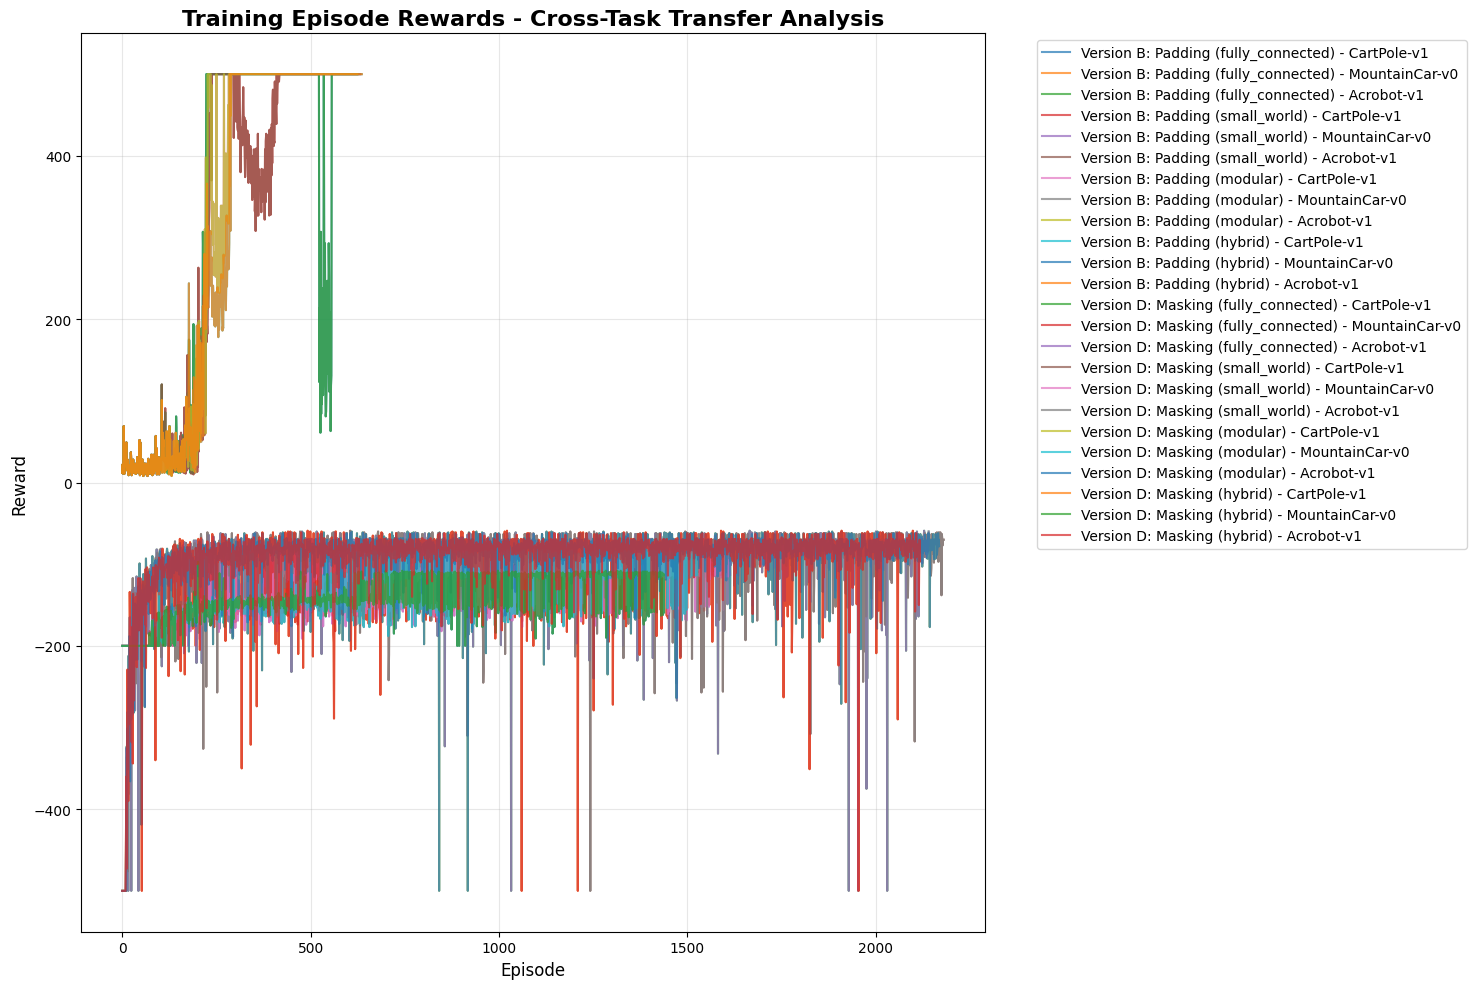

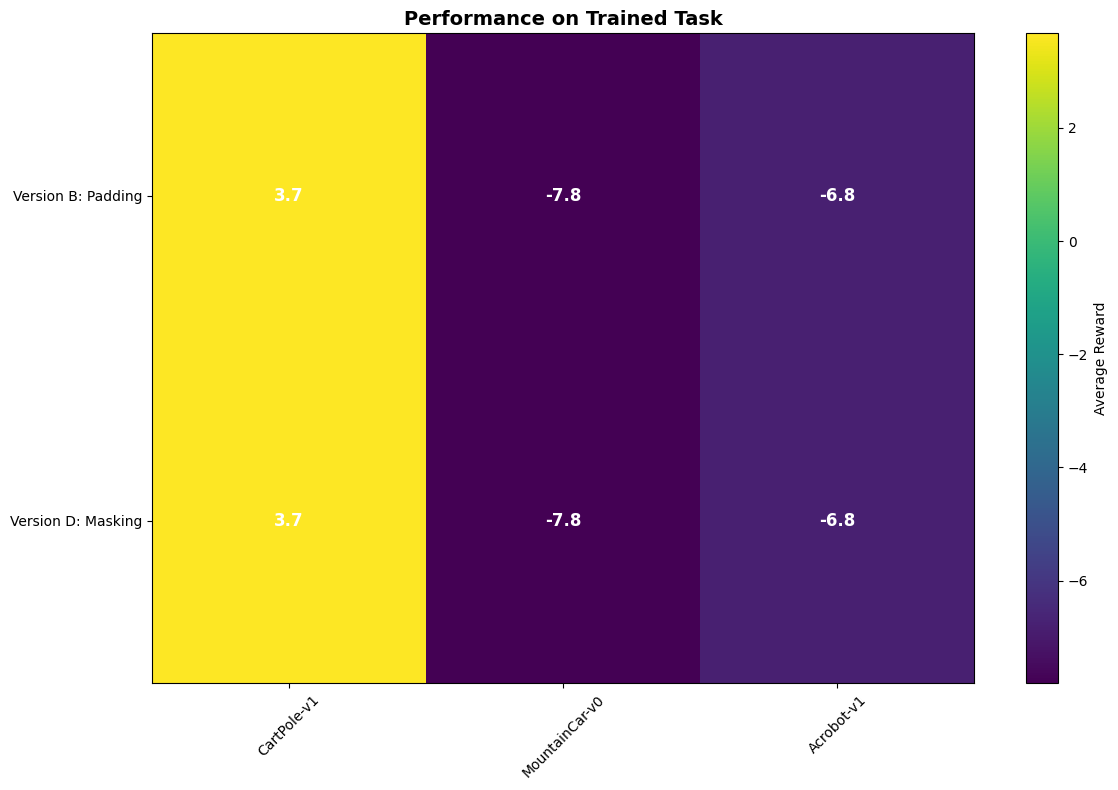

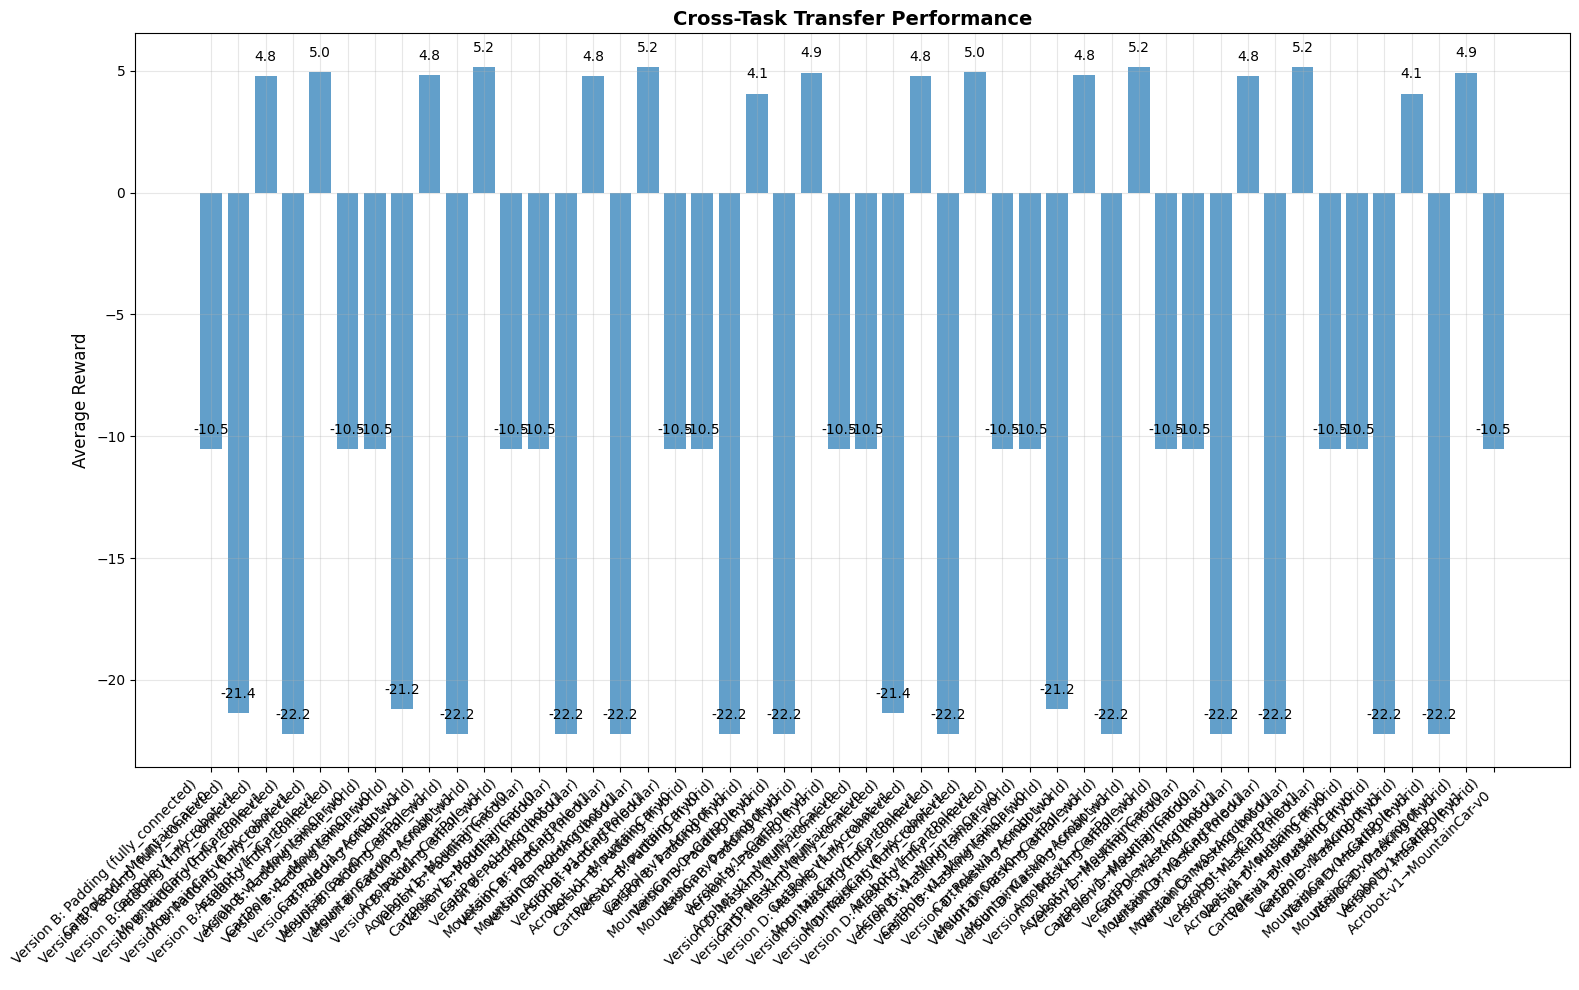

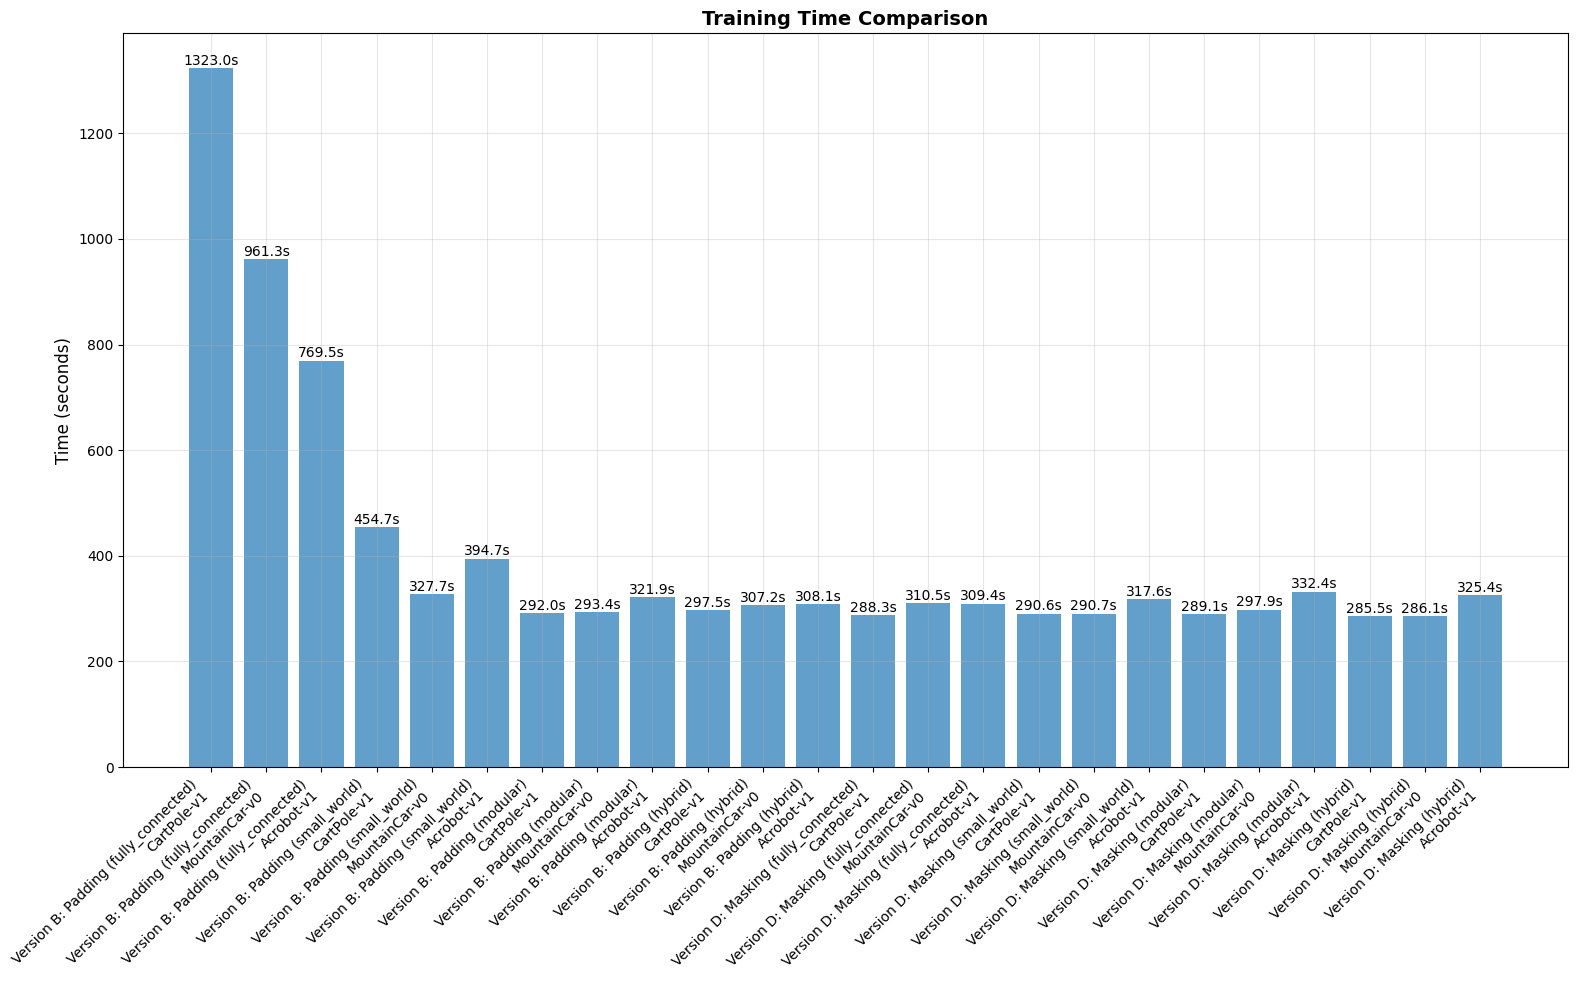

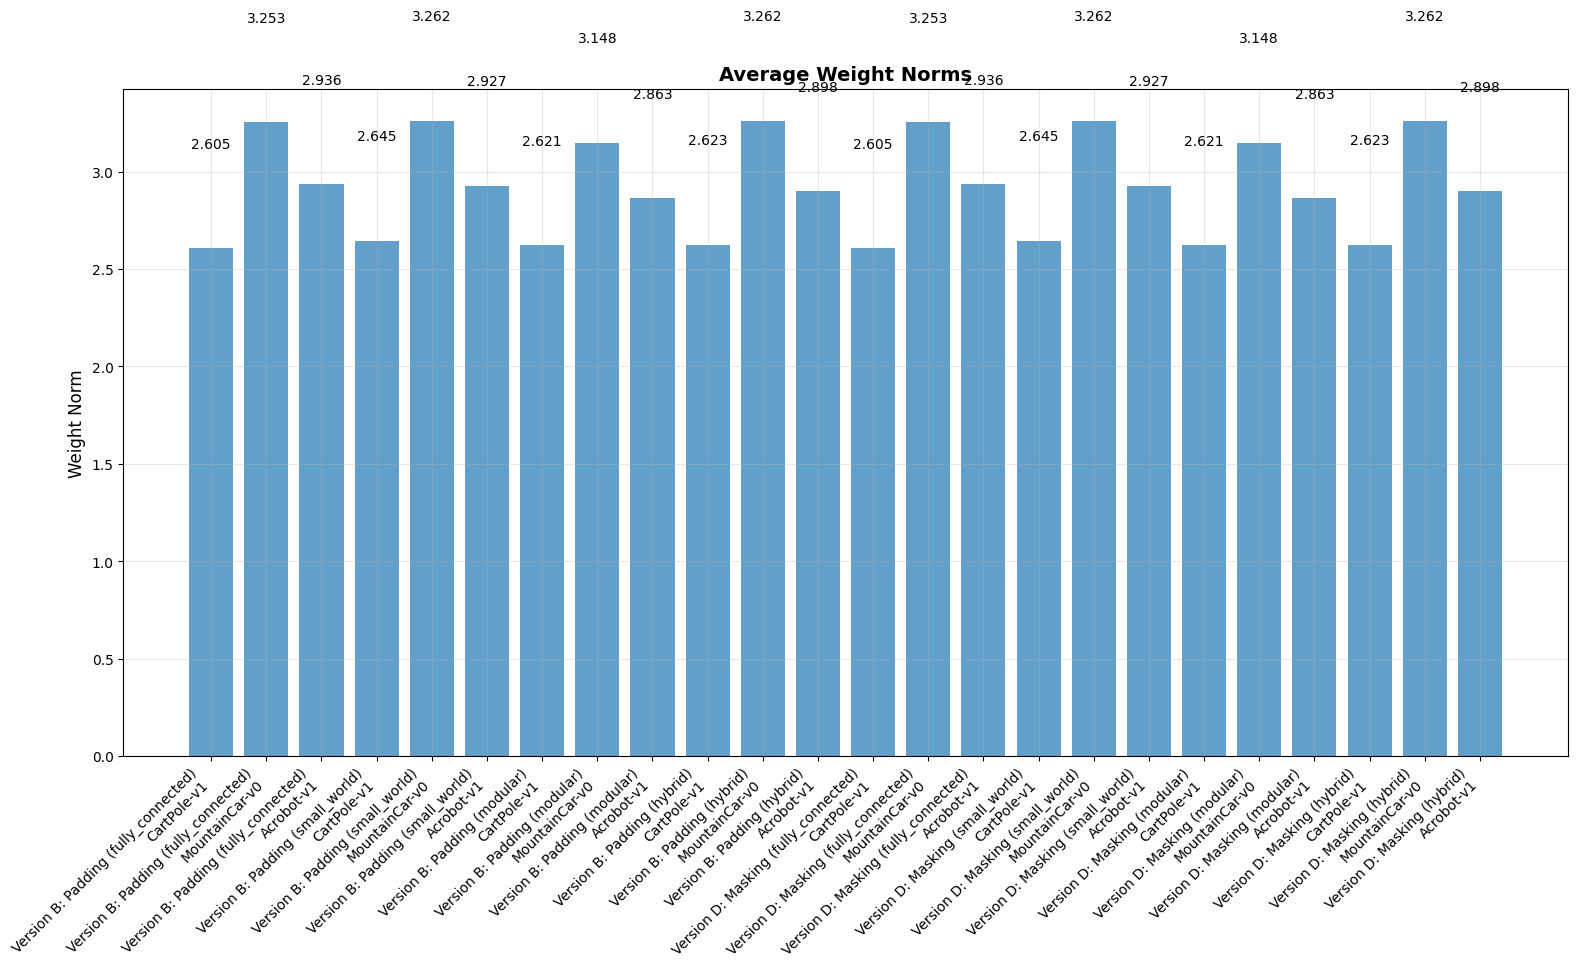

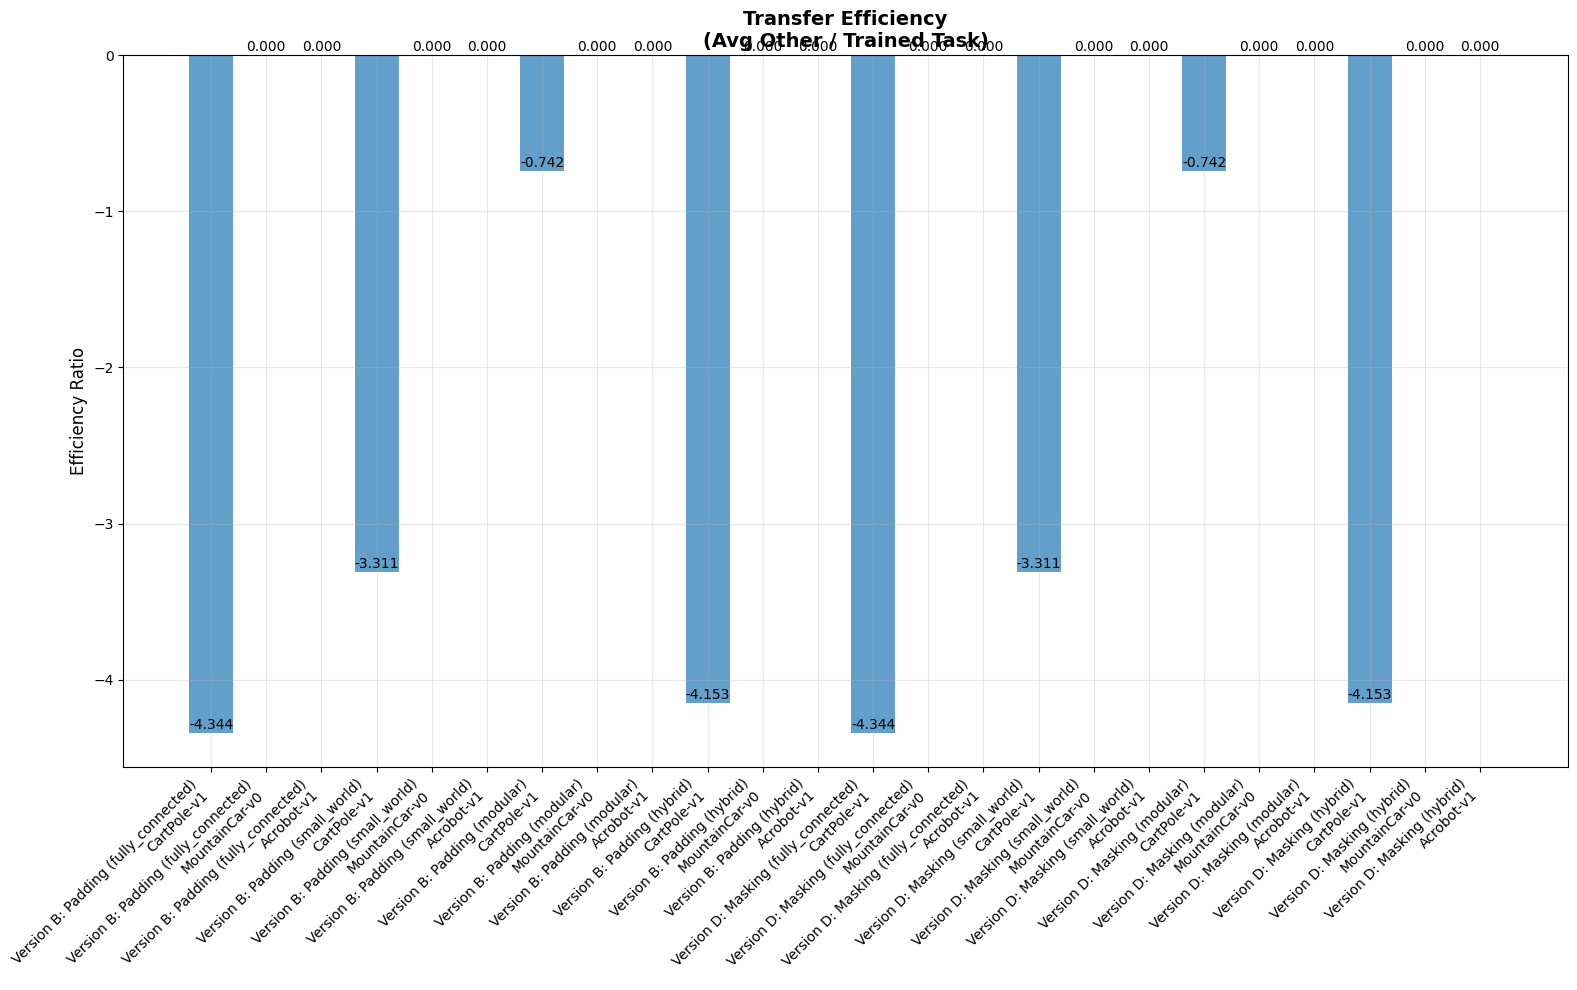

<Figure size 1400x800 with 0 Axes>

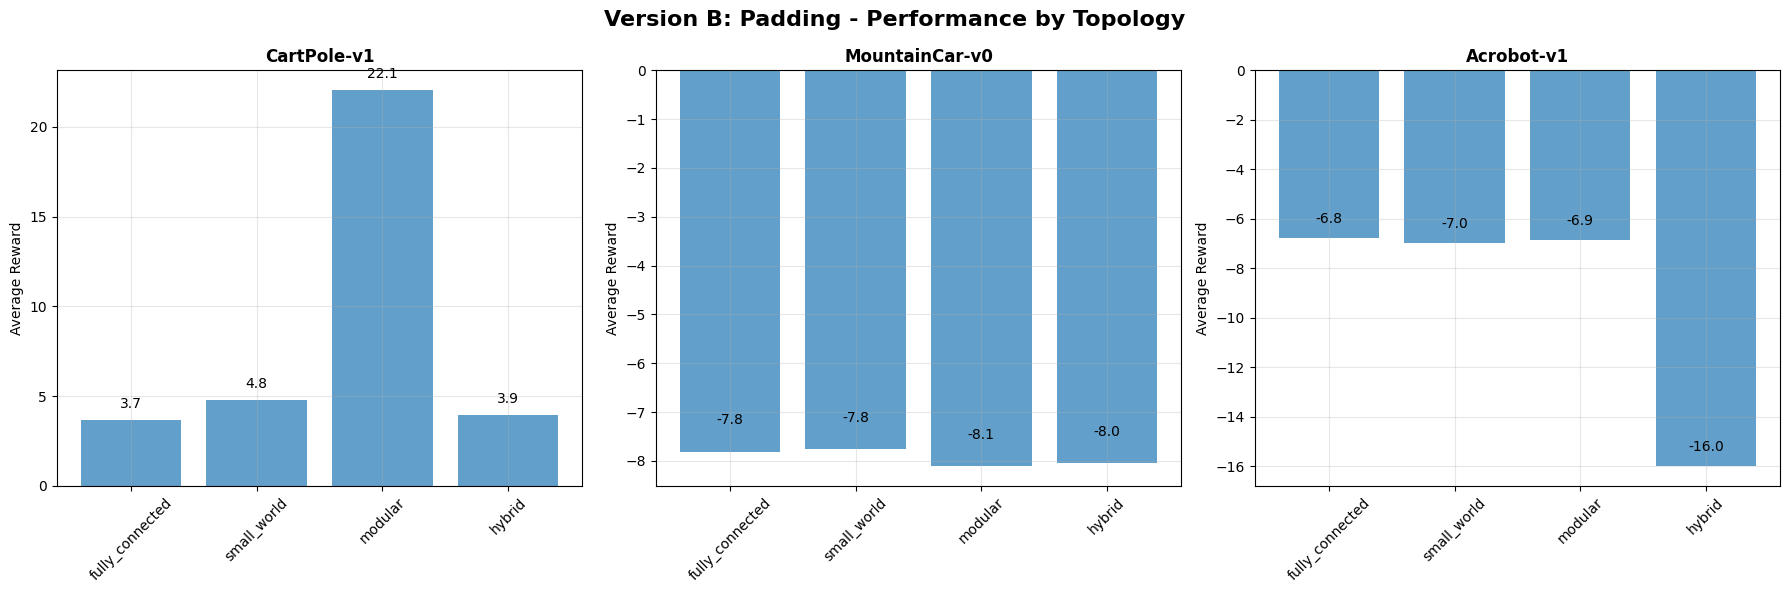

<Figure size 1400x800 with 0 Axes>

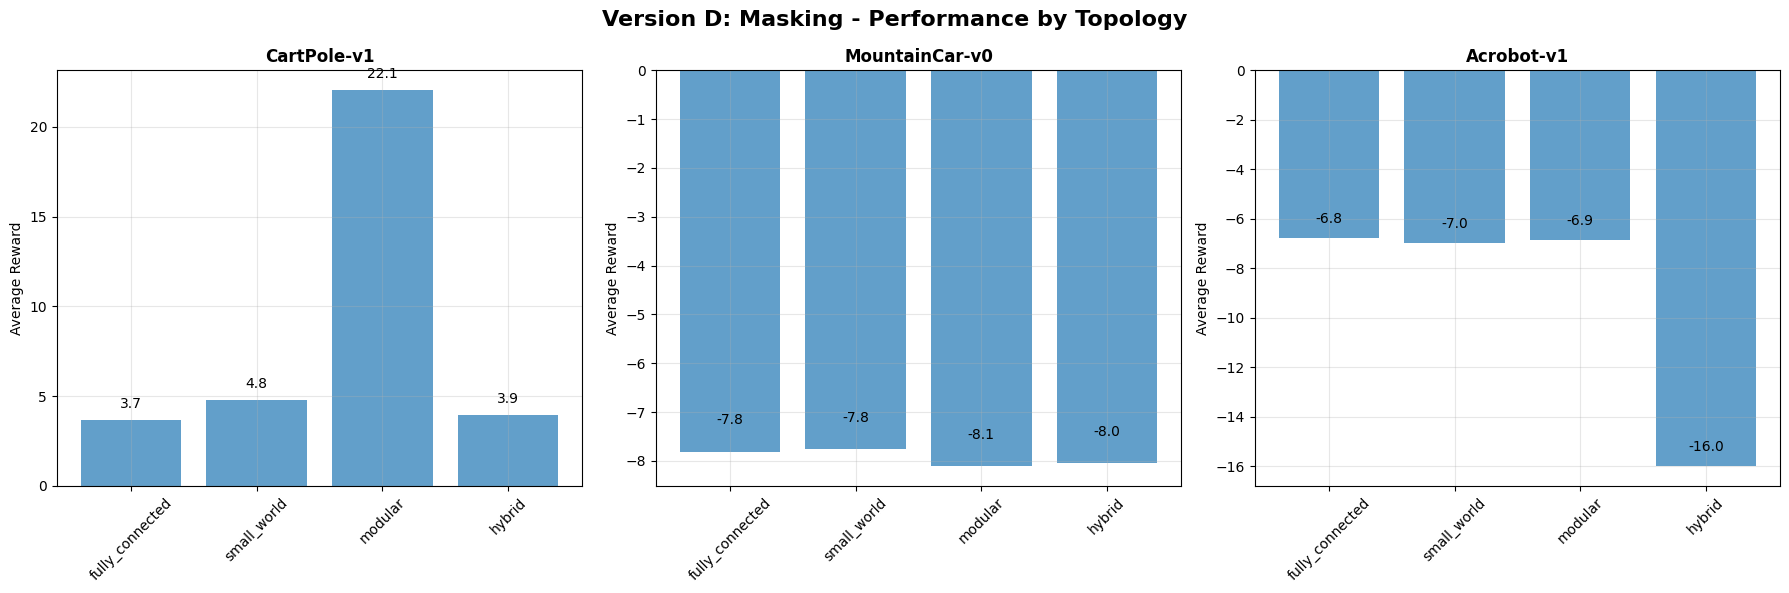

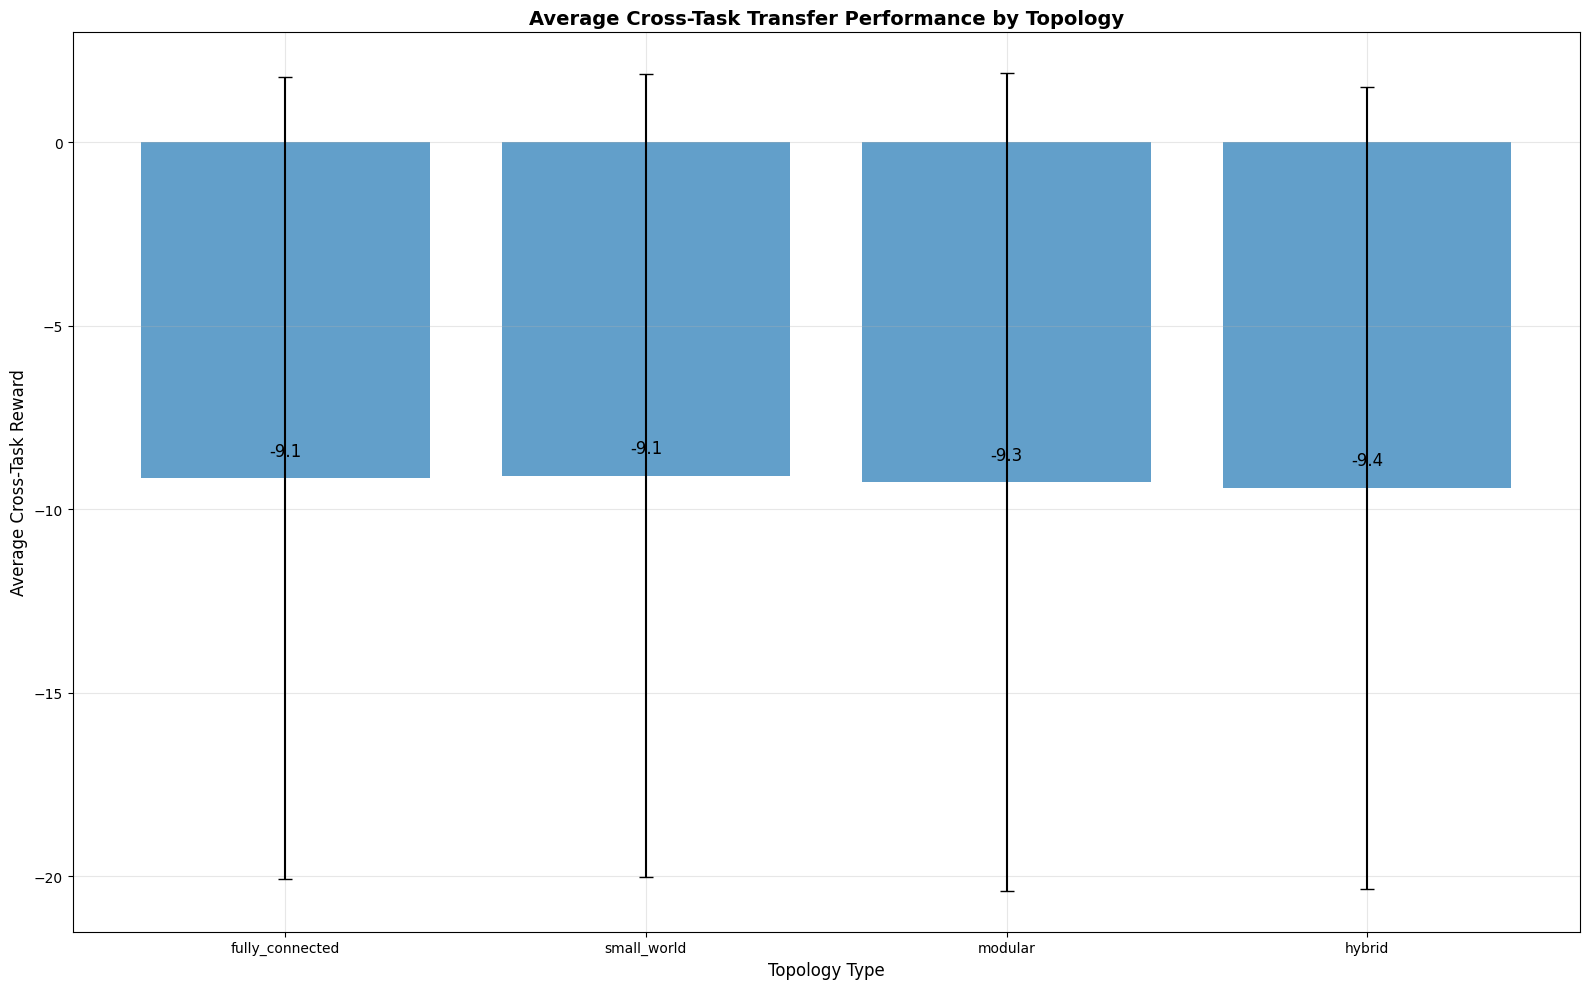

In [8]:

"""Create separate, readable visualizations for cross-task analysis."""

# Extract data for plotting
tasks = ['CartPole-v1', 'MountainCar-v0', 'Acrobot-v1']
versions = ['Version B: Padding', 'Version D: Masking']
topology_types = ['fully_connected', 'small_world', 'modular', 'hybrid']

# Create separate plots for better readability

# Plot 1: Training curves for each task
plt.figure(figsize=(15, 10))
plt.title('Training Episode Rewards - Cross-Task Transfer Analysis', fontsize=16, fontweight='bold')

for result in all_results:
    if result['training_episode_rewards']:
        label = f"{result['policy_name']} ({result['topology_type']}) - {result['train_task']}"
        plt.plot(result['training_episode_rewards'], label=label, alpha=0.7, linewidth=1.5)

plt.xlabel('Episode', fontsize=12)
plt.ylabel('Reward', fontsize=12)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cross_task_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Test performance matrix (heatmap)
plt.figure(figsize=(12, 8))
performance_matrix = np.zeros((len(versions), len(tasks)))

for i, version in enumerate(versions):
    for j, task in enumerate(tasks):
        # Find the result for this version and task
        for result in all_results:
            if result['policy_name'] == version and result['train_task'] == task:
                # Use performance on the same task (diagonal) or average across all test tasks
                if task in result['test_results']:
                    performance_matrix[i, j] = result['test_results'][task]['avg_reward']
                break

plt.imshow(performance_matrix, cmap='viridis', aspect='auto')
plt.xticks(range(len(tasks)), tasks, rotation=45)
plt.yticks(range(len(versions)), versions)
plt.title('Performance on Trained Task', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(versions)):
    for j in range(len(tasks)):
        text = plt.text(j, i, f'{performance_matrix[i, j]:.1f}',
                        ha="center", va="center", color="w", fontweight='bold', fontsize=12)

plt.colorbar(label='Average Reward')
plt.tight_layout()
plt.savefig('cross_task_performance_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Cross-task transfer performance
plt.figure(figsize=(16, 10))
transfer_scores = []
labels = []

for result in all_results:
    train_task = result['train_task']
    for test_task, test_result in result['test_results'].items():
        if test_task != train_task:  # Only cross-task transfers
            transfer_scores.append(test_result['avg_reward'])
            labels.append(f"{result['policy_name']} ({result['topology_type']})\n{train_task}→{test_task}")

if transfer_scores:
    bars = plt.bar(range(len(transfer_scores)), transfer_scores, alpha=0.7)
    plt.xticks(range(len(transfer_scores)), labels, rotation=45, ha='right', fontsize=10)
    plt.title('Cross-Task Transfer Performance', fontsize=14, fontweight='bold')
    plt.ylabel('Average Reward', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, score in zip(bars, transfer_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{score:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('cross_task_transfer_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4: Training time comparison
plt.figure(figsize=(16, 10))
training_times = []
time_labels = []

for result in all_results:
    training_times.append(result['training_time'])
    time_labels.append(f"{result['policy_name']} ({result['topology_type']})\n{result['train_task']}")

bars = plt.bar(range(len(training_times)), training_times, alpha=0.7)
plt.xticks(range(len(training_times)), time_labels, rotation=45, ha='right', fontsize=10)
plt.title('Training Time Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Time (seconds)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, time_val in zip(bars, training_times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{time_val:.1f}s', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('cross_task_training_times.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 5: Weight statistics comparison
plt.figure(figsize=(16, 10))
weight_norms = []
weight_labels = []

for result in all_results:
    if result['weight_stats']:
        # Get average weight norm across all parameters
        norms = []
        for param_stats in result['weight_stats'].values():
            if isinstance(param_stats, dict) and 'norm' in param_stats:
                norms.append(param_stats['norm'])
        if norms:
            weight_norms.append(np.mean(norms))
            weight_labels.append(f"{result['policy_name']} ({result['topology_type']})\n{result['train_task']}")

if weight_norms:
    bars = plt.bar(range(len(weight_norms)), weight_norms, alpha=0.7)
    plt.xticks(range(len(weight_norms)), weight_labels, rotation=45, ha='right', fontsize=10)
    plt.title('Average Weight Norms', fontsize=14, fontweight='bold')
    plt.ylabel('Weight Norm', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, norm_val in zip(bars, weight_norms):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{norm_val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('cross_task_weight_norms.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 6: Transfer efficiency (performance on trained task vs other tasks)
plt.figure(figsize=(16, 10))
transfer_efficiency = []
efficiency_labels = []

for result in all_results:
    train_task = result['train_task']
    if train_task in result['test_results']:
        trained_performance = result['test_results'][train_task]['avg_reward']
        
        # Calculate average performance on other tasks
        other_performances = []
        for test_task, test_result in result['test_results'].items():
            if test_task != train_task:
                other_performances.append(test_result['avg_reward'])
        
        if other_performances:
            avg_other_performance = np.mean(other_performances)
            efficiency = avg_other_performance / trained_performance if trained_performance > 0 else 0
            transfer_efficiency.append(efficiency)
            efficiency_labels.append(f"{result['policy_name']} ({result['topology_type']})\n{result['train_task']}")

if transfer_efficiency:
    bars = plt.bar(range(len(transfer_efficiency)), transfer_efficiency, alpha=0.7)
    plt.xticks(range(len(transfer_efficiency)), efficiency_labels, rotation=45, ha='right', fontsize=10)
    plt.title('Transfer Efficiency\n(Avg Other / Trained Task)', fontsize=14, fontweight='bold')
    plt.ylabel('Efficiency Ratio', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, eff_val in zip(bars, transfer_efficiency):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{eff_val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('cross_task_transfer_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 7: Topology comparison for each version
for version in versions:
    plt.figure(figsize=(14, 8))
    
    # Get data for this version
    version_results = [r for r in all_results if r['policy_name'] == version]
    
    # Create subplot for each task
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'{version} - Performance by Topology', fontsize=16, fontweight='bold')
    
    for task_idx, task in enumerate(tasks):
        ax = axes[task_idx]
        
        # Get results for this task
        task_results = [r for r in version_results if r['train_task'] == task]
        
        if task_results:
            topologies = [r['topology_type'] for r in task_results]
            performances = [r['test_results'][task]['avg_reward'] for r in task_results]
            
            bars = ax.bar(topologies, performances, alpha=0.7)
            ax.set_title(f'{task}', fontsize=12, fontweight='bold')
            ax.set_ylabel('Average Reward', fontsize=10)
            ax.tick_params(axis='x', rotation=45)
            ax.grid(True, alpha=0.3)
            
            # Add value labels on bars
            for bar, perf in zip(bars, performances):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                        f'{perf:.1f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'cross_task_{version.replace(" ", "_").replace(":", "")}_topology_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot 8: Cross-task transfer summary by topology
plt.figure(figsize=(16, 10))

# Calculate average cross-task transfer for each topology
topology_transfer_scores = {}

for result in all_results:
    topology = result['topology_type']
    if topology not in topology_transfer_scores:
        topology_transfer_scores[topology] = []
    
    train_task = result['train_task']
    for test_task, test_result in result['test_results'].items():
        if test_task != train_task:  # Only cross-task transfers
            topology_transfer_scores[topology].append(test_result['avg_reward'])

# Plot average transfer scores by topology
topologies = list(topology_transfer_scores.keys())
avg_transfer_scores = [np.mean(topology_transfer_scores[t]) for t in topologies]
std_transfer_scores = [np.std(topology_transfer_scores[t]) for t in topologies]

bars = plt.bar(topologies, avg_transfer_scores, yerr=std_transfer_scores, alpha=0.7, capsize=5)
plt.title('Average Cross-Task Transfer Performance by Topology', fontsize=14, fontweight='bold')
plt.ylabel('Average Cross-Task Reward', fontsize=12)
plt.xlabel('Topology Type', fontsize=12)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars, avg_transfer_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{score:.1f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('cross_task_topology_transfer_summary.png', dpi=300, bbox_inches='tight')
plt.show()



In [9]:

"""Print comprehensive summary of cross-task analysis."""
print("\n" + "=" * 120)
print("🌍 CROSS-TASK KNOWLEDGE TRANSFER ANALYSIS SUMMARY")
print("=" * 120)

tasks = ['CartPole-v1', 'MountainCar-v0', 'Acrobot-v1']

for task in tasks:
    print(f"\n🎯 RESULTS FOR TRAINING ON {task}")
    print("-" * 80)
    
    task_results = [r for r in all_results if r['train_task'] == task]
    
    for result in task_results:
        print(f"\n📊 {result['policy_name']} ({result['topology_type']})")
        print(f"   Training Time: {result['training_time']:.1f}s")
        
        # Performance on trained task
        if task in result['test_results']:
            trained_perf = result['test_results'][task]
            print(f"   Performance on {task}: {trained_perf['avg_reward']:.2f} ± {trained_perf['std_reward']:.2f}")
        
        # Performance on other tasks
        print("   Cross-Task Performance:")
        for test_task, test_result in result['test_results'].items():
            if test_task != task:
                print(f"     {test_task}: {test_result['avg_reward']:.2f} ± {test_result['std_reward']:.2f}")

# Compare versions
print(f"\n🔍 VERSION COMPARISON")
print("-" * 80)

for task in tasks:
    print(f"\n📈 {task} Training Results:")
    task_results = [r for r in all_results if r['train_task'] == task]
    
    for result in task_results:
        version = result['policy_name'] + ' (' + result['topology_type'] + ')'
        trained_perf = result['test_results'][task]['avg_reward']
        other_tasks = [test_task for test_task in result['test_results'].keys() if test_task != task]
        avg_other_perf = np.mean([result['test_results'][t]['avg_reward'] for t in other_tasks])
        
        print(f"   {version}:")
        print(f"     Trained task performance: {trained_perf:.2f}")
        print(f"     Average other task performance: {avg_other_perf:.2f}")
        print(f"     Transfer efficiency: {avg_other_perf/trained_perf:.3f}")


🌍 CROSS-TASK KNOWLEDGE TRANSFER ANALYSIS SUMMARY

🎯 RESULTS FOR TRAINING ON CartPole-v1
--------------------------------------------------------------------------------

📊 Version B: Padding (fully_connected)
   Training Time: 1323.0s
   Performance on CartPole-v1: 3.67 ± 6.64
   Cross-Task Performance:
     MountainCar-v0: -10.52 ± 6.98
     Acrobot-v1: -21.37 ± 5.21

📊 Version B: Padding (small_world)
   Training Time: 454.7s
   Performance on CartPole-v1: 4.79 ± 4.16
   Cross-Task Performance:
     MountainCar-v0: -10.52 ± 6.98
     Acrobot-v1: -21.18 ± 4.79

📊 Version B: Padding (modular)
   Training Time: 292.0s
   Performance on CartPole-v1: 22.05 ± 6.71
   Cross-Task Performance:
     MountainCar-v0: -10.52 ± 6.98
     Acrobot-v1: -22.21 ± 7.06

📊 Version B: Padding (hybrid)
   Training Time: 297.5s
   Performance on CartPole-v1: 3.94 ± 6.71
   Cross-Task Performance:
     MountainCar-v0: -10.52 ± 6.98
     Acrobot-v1: -22.21 ± 7.06

📊 Version D: Masking (fully_connected)
   Tr

In [10]:

print("\n💾 Saving results...")

# Save raw results
with open('cross_task_transfer_results.json', 'w') as f:
    def convert_numpy(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, dict):
            return {key: convert_numpy(value) for key, value in obj.items()}
        elif isinstance(obj, list):
            return [convert_numpy(item) for item in obj]
        else:
            return obj
    json.dump(all_results, f, default=convert_numpy, indent=2)

print("\n✅ Cross-task analysis completed!")
print("📁 Files created:")
print("  - cross_task_training_curves.png (training progress)")
print("  - cross_task_performance_matrix.png (performance heatmap)")
print("  - cross_task_transfer_performance.png (cross-task transfer)")
print("  - cross_task_training_times.png (training time comparison)")
print("  - cross_task_weight_norms.png (weight statistics)")
print("  - cross_task_transfer_efficiency.png (transfer efficiency)")
print("  - cross_task_Version_B_Padding_topology_comparison.png (Version B by topology)")
print("  - cross_task_Version_D_Masking_topology_comparison.png (Version D by topology)")
print("  - cross_task_topology_transfer_summary.png (topology summary)")
print("  - cross_task_transfer_results.json (raw data)")


💾 Saving results...

✅ Cross-task analysis completed!
📁 Files created:
  - cross_task_training_curves.png (training progress)
  - cross_task_performance_matrix.png (performance heatmap)
  - cross_task_transfer_performance.png (cross-task transfer)
  - cross_task_training_times.png (training time comparison)
  - cross_task_weight_norms.png (weight statistics)
  - cross_task_transfer_efficiency.png (transfer efficiency)
  - cross_task_Version_B_Padding_topology_comparison.png (Version B by topology)
  - cross_task_Version_D_Masking_topology_comparison.png (Version D by topology)
  - cross_task_topology_transfer_summary.png (topology summary)
  - cross_task_transfer_results.json (raw data)
